Number of points on the Pareto front: 668


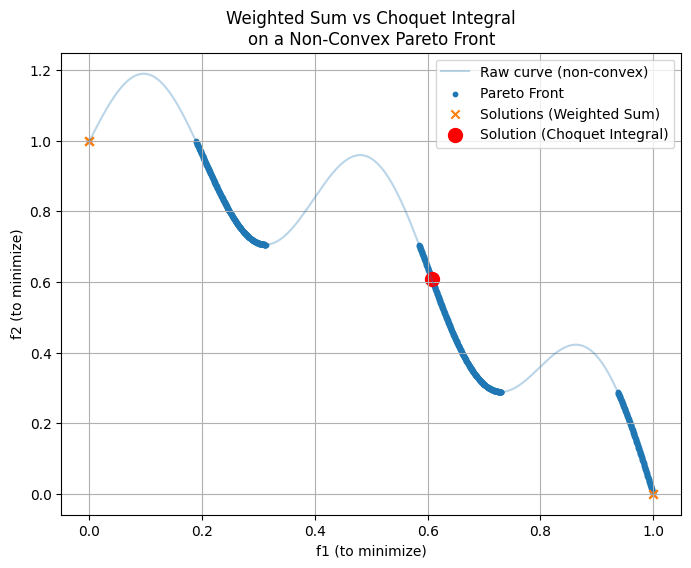

In [2]:
# -*- coding: utf-8 -*-
"""
Multi-Objective Optimization Example
Comparison between Weighted Sum and Choquet Integral
on a non-convex Pareto front
"""

import numpy as np
import matplotlib.pyplot as plt

# 1. Generate the test problem - Non-convex Pareto front

# Create 2000 points evenly spaced between 0 and 1
x = np.linspace(0, 1, 2000)

# Objective 1: linear
f1 = x

# Objective 2: quadratic with oscillations to create non-convexity
f2 = 1 - x**2 + 0.2 * np.sin(5 * np.pi * x)

# Combine both objectives into a single array of points
points = np.column_stack((f1, f2))


# 2. Pareto Front Filtering (Minimization)

# Identify non-dominated points (Pareto optimal solutions)
# A point p is dominated if there exists another point q that is
# better or equal in both objectives, and strictly better in at least one.

pareto = []

for i, p in enumerate(points):
    dominated = False
    for j, q in enumerate(points):
        # Check if q dominates p
        if (q[0] <= p[0] and q[1] <= p[1]) and (q[0] < p[0] or q[1] < p[1]):
            dominated = True
            break
    if not dominated:
        pareto.append(p)

pareto = np.array(pareto)

print(f"Number of points on the Pareto front: {len(pareto)}")


# 3. Weighted Sum Method (Linear Scalarization)

# This function converts two objectives into one using a weight w
def weighted_sum(f1, f2, w):
    """Compute weighted sum: w*f1 + (1-w)*f2"""
    return w * f1 + (1 - w) * f2

# Test several weight values from 0 to 1
weights = np.linspace(0, 1, 5)
ws_points = []

for w in weights:
    # For each weight, find the point that minimizes the weighted sum
    J = weighted_sum(f1, f2, w)
    idx = np.argmin(J)
    ws_points.append((f1[idx], f2[idx]))

ws_points = np.array(ws_points)


# 4. Choquet Integral (for 2 criteria)

# The Choquet integral is a non-linear aggregation method that can model
# interactions between objectives using a fuzzy measure (mu1, mu2, mu12)
def choquet(f1, f2, mu1=0.4, mu2=0.4, mu12=1.0):
    """
    Compute the Choquet integral for two objectives.

    Parameters:
        mu1: importance of f1 alone
        mu2: importance of f2 alone
        mu12: importance of both objectives together (interaction term)
    """
    C = np.zeros_like(f1)
    for i in range(len(f1)):
        a, b = f1[i], f2[i]
        if a <= b:
            # f1 is the smaller (better) value
            C[i] = a * mu1 + (b - a) * mu12
        else:
            # f2 is the smaller (better) value
            C[i] = b * mu2 + (a - b) * mu12
    return C

# Compute Choquet values and find the best solution
C = choquet(f1, f2)
idx_choquet = np.argmin(C)


# 5. Visualization

plt.figure(figsize=(8, 6))

# Plot the original raw curve (light transparency)
plt.plot(f1, f2, alpha=0.3, label="Raw curve (non-convex)")

# Plot the actual Pareto front
plt.scatter(pareto[:, 0], pareto[:, 1],
            label="Pareto Front", s=10)

# Plot solutions found by weighted sum
plt.scatter(ws_points[:, 0], ws_points[:, 1],
            label="Solutions (Weighted Sum)",
            marker='x')

# Highlight the solution found by Choquet integral
plt.scatter(f1[idx_choquet], f2[idx_choquet],
            color='red', s=100,
            label="Solution (Choquet Integral)")

plt.xlabel("f1 (to minimize)")
plt.ylabel("f2 (to minimize)")
plt.title("Weighted Sum vs Choquet Integral\non a Non-Convex Pareto Front")
plt.legend()
plt.grid(True)

plt.show()